Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [1]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
# Start coding here
# Use as many cells as you need

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Integrity Check

In [9]:
# We check for missing values (NaNs).
# In raw data, this tells us which fields are optional or poorly recorded.
print("Count of Missing Values per Column:")
print(crimes.isnull().sum())
crimes.info()

Count of Missing Values per Column:
DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  

In [10]:
crimes.describe()

,DR_NO,Vict Age
count,1.857150e+05,185715.000000
mean,2.255781e+08,39.999257
std,5.017438e+06,15.450227
min,2.009072e+08,2.000000
25%,2.210108e+08,28.000000
50%,2.220114e+08,37.000000
75%,2.310044e+08,50.000000
max,2.399097e+08,99.000000


# 2. Handle missing values

In [11]:
crimes.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,11
Vict Descent,10
Weapon Desc,112213


In [16]:
crimes['Weapon Desc'] = crimes['Weapon Desc'].fillna('Unknown')
crimes['Vict Descent'] = crimes['Vict Descent'].fillna('Unknown')
crimes['Vict Sex'] = crimes['Vict Sex'].fillna('Unknown')

In [17]:
# Ensure that there's no missing value
crimes.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,0


# 3. Remove duplicates

In [19]:
crimes.duplicated().sum()

np.int64(0)

In [20]:
# There's no duplicated Values

# 4. Fix column names (make them clean and consistent)

In [26]:
crimes.columns = crimes.columns.str.strip().str.lower().str.replace(' ', '_')

# 5. Convert data types

In [24]:
print(crimes.columns)

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area_name',
       'crm_cd_desc', 'vict_age', 'vict_sex', 'vict_descent', 'weapon_desc',
       'status_desc', 'location'],
      dtype='object')


In [28]:
crimes['date_rptd'] = pd.to_datetime(crimes['date_rptd'], errors='coerce')
crimes['date_occ'] = pd.to_datetime(crimes['date_occ'], errors='coerce')

In [30]:
crimes['time_occ'] = pd.to_datetime(crimes['time_occ'], format='%H%M', errors='coerce').dt.time

In [31]:
# Ensure changes
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   dr_no         185715 non-null  int64         
 1   date_rptd     185715 non-null  datetime64[ns]
 2   date_occ      185715 non-null  datetime64[ns]
 3   time_occ      185715 non-null  object        
 4   area_name     185715 non-null  object        
 5   crm_cd_desc   185715 non-null  object        
 6   vict_age      185715 non-null  int64         
 7   vict_sex      185715 non-null  object        
 8   vict_descent  185715 non-null  object        
 9   weapon_desc   185715 non-null  object        
 10  status_desc   185715 non-null  object        
 11  location      185715 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 17.0+ MB


In [32]:
crimes['vict_age'].describe()

,vict_age
count,185715.000000
mean,39.999257
std,15.450227
min,2.000000
25%,28.000000
50%,37.000000
75%,50.000000
max,99.000000


In [33]:
crimes.loc[crimes['vict_age'] <= 0, 'vict_age'] = None

# 6. Handle outliers (optional but useful)

In [40]:
Q1 = crimes['vict_age'].quantile(0.25)
Q3 = crimes['vict_age'].quantile(0.75)
IQR = Q3 - Q1

outliers = crimes[(crimes['vict_age'] < Q1 - 1.5 * IQR) |
                  (crimes['vict_age'] > Q3 + 1.5 * IQR)]

outliers

,dr_no,date_rptd,date_occ,time_occ,area_name,crm_cd_desc,vict_age,vict_sex,vict_descent,weapon_desc,status_desc,location
54,221511140,2022-06-14,2020-01-01,12:35:00,N Hollywood,THEFT OF IDENTITY,87.0,Unknown,Unknown,Unknown,Invest Cont,11300 OTSEGO ST
116,221714096,2022-09-27,2020-01-09,12:00:00,Devonshire,"CREDIT CARDS, FRAUD USE ($950 & UNDER",84.0,Unknown,Unknown,Unknown,Invest Cont,19300 ROMAR ST
119,221515500,2022-09-29,2020-09-01,09:05:00,N Hollywood,THEFT OF IDENTITY,86.0,Unknown,Unknown,Unknown,Invest Cont,11300 OTSEGO ST
304,221610845,2022-07-26,2020-02-01,12:00:00,Foothill,BURGLARY,84.0,Unknown,Unknown,Unknown,Invest Cont,11700 GLENCREST DR
314,221515089,2022-09-14,2020-01-01,15:50:00,N Hollywood,THEFT OF IDENTITY,87.0,Unknown,Unknown,Unknown,Invest Cont,11300 OTSEGO ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185302,230907157,2023-03-21,2023-03-17,18:13:00,Van Nuys,SHOPLIFTING - PETTY THEFT ($950 & UNDER),99.0,Unknown,Unknown,Unknown,Invest Cont,14900 RAYMER ST
185339,230810854,2023-06-14,2023-06-08,00:05:00,West LA,OTHER MISCELLANEOUS CRIME,99.0,Unknown,Unknown,Unknown,Invest Cont,1300 GOUCHER ST
185354,231507385,2023-03-21,2023-03-21,19:00:00,N Hollywood,CONTEMPT OF COURT,84.0,Unknown,Unknown,Unknown,Adult Arrest,6300 BECK AV
185447,230900863,2023-05-27,2023-05-26,16:00:00,Van Nuys,"THEFT, PERSON",93.0,Unknown,Unknown,Unknown,Invest Cont,VENTURA BL


In [37]:
outliers.shape[0]

1218

In [38]:
crimes['vict_age'].describe()

,vict_age
count,185715.000000
mean,39.999257
std,15.450227
min,2.000000
25%,28.000000
50%,37.000000
75%,50.000000
max,99.000000


# 7. Standardize text values

In [42]:
crimes['location'] = crimes['location'].str.lower().str.strip()

# 8. Save cleaned data

In [44]:
crimes.to_csv('/content/crimes.csv', index=False)

# Q1: Most Common Crimes


Top 10 Crimes:
 crm_cd_desc
THEFT OF IDENTITY                                           22670
BATTERY - SIMPLE ASSAULT                                    19694
BURGLARY FROM VEHICLE                                       13799
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              13215
INTIMATE PARTNER - SIMPLE ASSAULT                           11981
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         11484
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     10719
THEFT PLAIN - PETTY ($950 & UNDER)                          10603
BURGLARY                                                    10268
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     7057
Name: count, dtype: int64


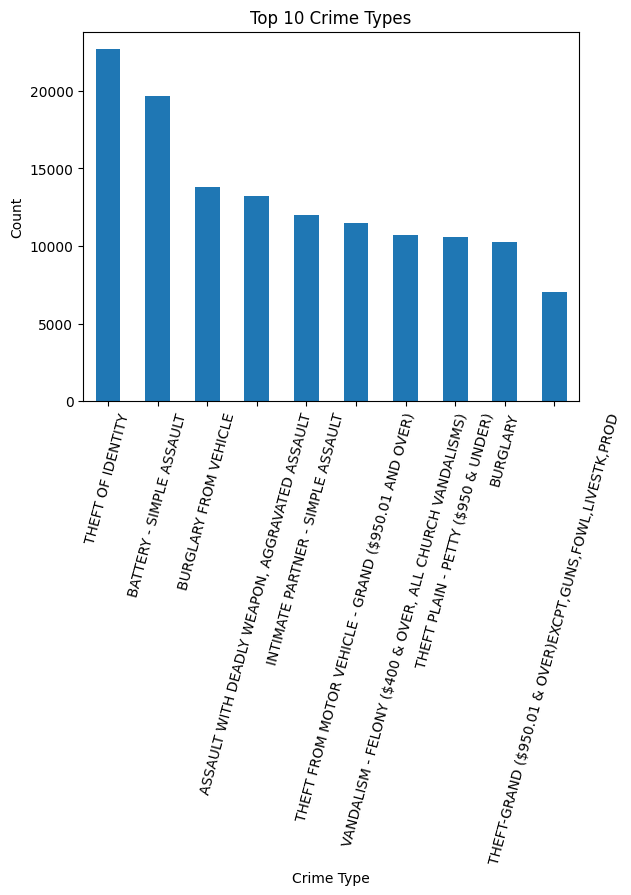

In [46]:
top_crimes = crimes['crm_cd_desc'].value_counts().head(10)
print("\nTop 10 Crimes:\n", top_crimes)

# Plot
top_crimes.plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

# Q2: Crimes by Hour


Crimes by Hour:
 time_occ
00:01:00    3587
00:02:00      83
00:03:00      73
00:04:00      55
00:05:00     652
            ... 
23:55:00     185
23:56:00      12
23:57:00       5
23:58:00      18
23:59:00     115
Name: count, Length: 1439, dtype: int64


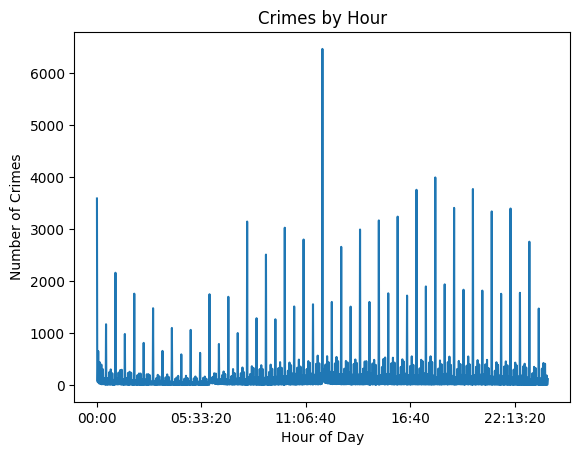

In [47]:
crimes_by_hour = crimes['time_occ'].value_counts().sort_index()
print("\nCrimes by Hour:\n", crimes_by_hour)

# Plot
crimes_by_hour.plot(kind='line')
plt.title("Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.show()

# Q3: Most Dangerous Areas


Top 10 Areas:
 area_name
Central        14944
Southwest      11945
77th Street    11739
Pacific         9923
Hollywood       9762
Southeast       9571
Olympic         9414
Newton          9152
Van Nuys        8621
N Hollywood     8502
Name: count, dtype: int64


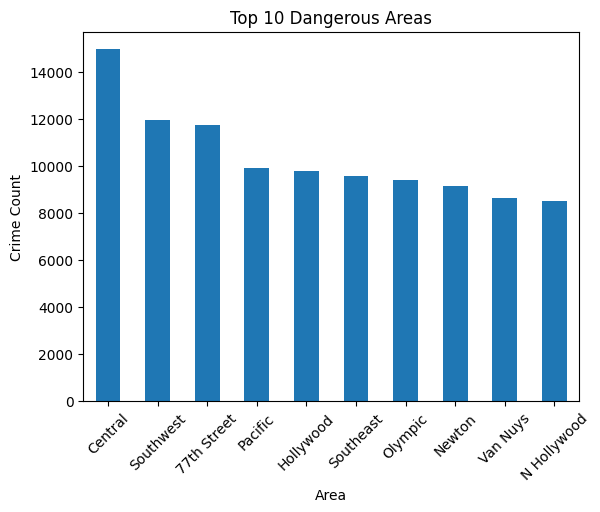

In [49]:
top_areas = crimes['area_name'].value_counts().head(10)
print("\nTop 10 Areas:\n", top_areas)

# Plot
top_areas.plot(kind='bar')
plt.title("Top 10 Dangerous Areas")
plt.xlabel("Area")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.show()

# Q4: Victim Age Distribution


Victim Age Stats:
 count    185715.000000
mean         39.999257
std          15.450227
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: vict_age, dtype: float64


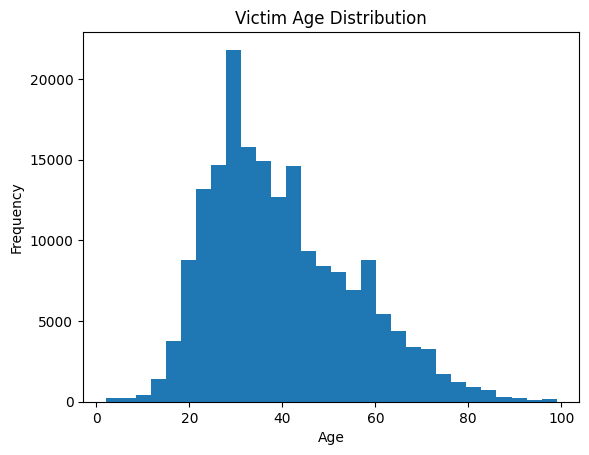

In [52]:
print("\nVictim Age Stats:\n", crimes['vict_age'].describe())

# Plot
crimes['vict_age'].plot(kind='hist', bins=30)
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Q5: Crimes by Month


Crimes by Month:
 date_occ
2020-01-01     72
2020-01-02      5
2020-01-03      1
2020-01-04      2
2020-01-05      2
             ... 
2023-06-29    342
2023-06-30    315
2023-07-01    378
2023-07-02    259
2023-07-03     48
Name: count, Length: 1152, dtype: int64


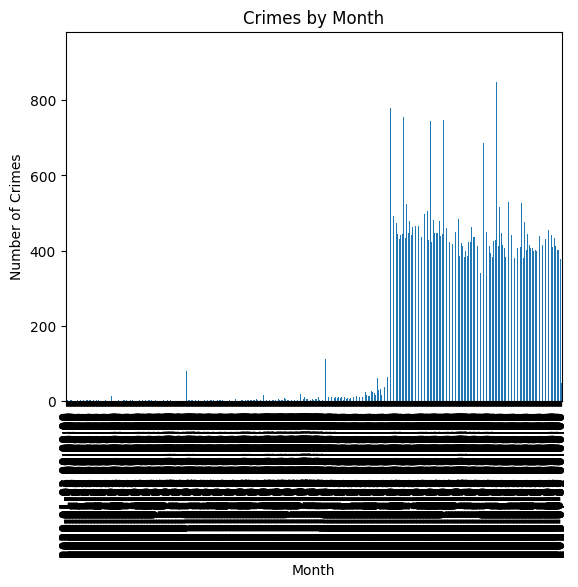

In [54]:
crimes_by_month = crimes['date_occ'].value_counts().sort_index()
print("\nCrimes by Month:\n", crimes_by_month)

# Plot
crimes_by_month.plot(kind='bar')
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

---

## 📌 Summary of Insights

### 1️⃣ Most Common Crimes

* **Identity theft** is the most frequent crime by a large margin.
* Other major crimes include **assault** and **vehicle-related theft**.
  👉 **Insight:** Crime is largely driven by **financial fraud and everyday urban crimes**, not just violent offenses.

---

### 2️⃣ Crimes by Time (Hour)

* Crime peaks around **midday (12 PM)** and stays high into the **evening (3 PM – 8 PM)**.
  👉 **Insight:** Crimes occur more during **active daytime hours**, not just late at night as commonly assumed.

---

### 3️⃣ Most Dangerous Areas

* Areas like **Central, Southwest, and 77th Street** have the highest crime rates.
  👉 **Insight:** Crime is **geographically concentrated**, likely linked to population density and busy urban activity.

---

### 4️⃣ Victim Age Distribution

* Most victims are between **28 and 50 years old**, with an average age around **40**.
  👉 **Insight:** Crimes mainly affect **working-age adults**, not predominantly young or elderly groups.

---

### 5️⃣ Crimes by Month

* **June shows a significant spike** compared to other months.
  👉 **Insight:** There may be **seasonal patterns** or anomalies in crime occurrence that need further investigation.

---

## 🔥 Final Big Picture

* Crime patterns are influenced by **time, location, and demographics**
* The dataset highlights a mix of:

  * **non-violent financial crimes**
  * **common urban incidents (assault, theft)**
* Crime is **predictable to some extent**, which is useful for planning prevention strategies
